# Expériences de robustesse pour la reconnaissance bioacoustique des oiseaux

## Objectif

Ce notebook étudie expérimentalement la robustesse de **BirdNET 3.0** face à plusieurs perturbations pouvant apparaître dans des enregistrements bioacoustiques réels.

Trois expériences contrôlées sont réalisées :

1. **bruit de fond** : influence du rapport signal/bruit (SNR) sur la confiance d'une espèce cible ;
2. **vocalisations simultanées** : influence du poids relatif de deux espèces superposées ;
3. **seuil de confiance** : influence du seuil sur le nombre de détections et d'espèces conservées.

Les résultats numériques sont exportés au format CSV et les figures au format PNG dans `results/`.

> **Périmètre.** Il s'agit de tests contrôlés sur un fichier d'exemple. Ils servent à observer le comportement du modèle dans des situations précises, et non à mesurer sa performance globale sur un jeu de données annoté.


## 1. Environnement, architecture et reproductibilité

Le notebook utilise le backend **ONNX** de BirdNET et une graine aléatoire fixée à `42`.

Les dépendances sont définies par `pyproject.toml` et verrouillées par `uv.lock`. Pour recréer l'environnement :

```bash
uv sync --frozen
uv run jupyter lab
```


In [16]:
from __future__ import annotations

from dataclasses import dataclass
from importlib.metadata import PackageNotFoundError, version
from numbers import Real
from os import environ
from pathlib import Path
from platform import python_version
from typing import ClassVar, Protocol, Self, TypeAlias, cast
from urllib.request import urlretrieve

# Disable ONNX Runtime telemetry before importing BirdNET.
environ.setdefault("ORT_DISABLE_TELEMETRY", "1")

from IPython.display import Audio, display
from matplotlib.axes import Axes
from matplotlib.collections import QuadMesh
from matplotlib.figure import Figure
from matplotlib.pyplot import show, subplots
from numpy import (
    absolute,
    amax,
    asarray,
    float32,
    float64,
    inf,
    isfinite,
    log10,
    maximum,
    mean,
    sqrt,
    square,
)
from numpy.random import Generator, default_rng
from numpy.typing import NDArray
from pandas import DataFrame, Series, read_csv, to_numeric
from pydantic import BaseModel, ConfigDict, Field, model_validator
from scipy.signal import spectrogram
from soundfile import read, write

from birdnet import load

FloatArray: TypeAlias = NDArray[float32]
Float64Array: TypeAlias = NDArray[float64]


In [17]:
class CsvWritable(Protocol):
    """Describe a prediction object that can be exported to CSV."""

    def to_csv(self, path: str) -> object:
        """Export predictions to a CSV file.

        :param path: Destination CSV path.
        :type path: str
        :return: Backend-specific export result.
        :rtype: object
        """
        ...


class BirdNetModelProtocol(Protocol):
    """Describe the BirdNET model methods used by this notebook."""

    def predict(self, audio_path: str) -> CsvWritable:
        """Run BirdNET inference on an audio file.

        :param audio_path: Audio file path.
        :type audio_path: str
        :return: Prediction object exposing CSV export.
        :rtype: CsvWritable
        """
        ...


@dataclass(frozen=True, slots=True)
class ProjectPaths:
    """Store immutable project paths."""

    root: Path
    data: Path
    results: Path
    generated_audio: Path

    @classmethod
    def from_working_directory(cls) -> Self:
        """Build project paths from the current working directory.

        :return: Project path configuration.
        :rtype: ProjectPaths
        """
        root: Path = Path.cwd()
        return cls(
            root=root,
            data=root / "data",
            results=root / "results",
            generated_audio=root / "generated_audio",
        )

    def create_directories(self) -> None:
        """Create all writable project directories.

        :return: None.
        :rtype: None
        """
        directories: tuple[Path, ...] = (
            self.data,
            self.results,
            self.generated_audio,
        )
        for directory_value in directories:
            directory: Path = directory_value
            directory.mkdir(parents=True, exist_ok=True)


@dataclass(frozen=True, slots=True)
class AudioSource:
    """Store the immutable source audio description."""

    url: str
    filename: str


@dataclass(frozen=True, slots=True)
class ModelSettings:
    """Store immutable BirdNET model parameters."""

    family: str = "acoustic"
    version: str = "3.0"
    backend: str = "onnx"


@dataclass(frozen=True, slots=True)
class MixRatio:
    """Store one immutable pair of amplitude coefficients."""

    first: float
    second: float

    def __post_init__(self) -> None:
        """Validate amplitude coefficients.

        :return: None.
        :rtype: None
        """
        if self.first < 0.0 or self.second < 0.0:
            raise ValueError("Mix weights must be non-negative.")
        if self.first + self.second == 0.0:
            raise ValueError("At least one mix weight must be greater than zero.")

    @property
    def label(self) -> str:
        """Return a percentage-style label for the mix ratio.

        :return: Mix ratio label.
        :rtype: str
        """
        first_percent: int = int(round(self.first * 100.0))
        second_percent: int = int(round(self.second * 100.0))
        return f"{first_percent}/{second_percent}"


@dataclass(frozen=True, slots=True)
class ExperimentSettings:
    """Store immutable experiment parameters."""

    random_seed: int = 42
    snr_values_db: tuple[float, ...] = (20.0, 10.0, 5.0, 0.0)
    mix_ratios: tuple[MixRatio, ...] = (
        MixRatio(0.50, 0.50),
        MixRatio(0.75, 0.25),
        MixRatio(0.90, 0.10),
    )
    confidence_thresholds: tuple[float, ...] = (0.10, 0.25, 0.50, 0.75)

    def __post_init__(self) -> None:
        """Validate experiment parameters.

        :return: None.
        :rtype: None
        """
        invalid_thresholds: tuple[float, ...] = tuple(
            threshold_value
            for threshold_value in self.confidence_thresholds
            if not 0.0 <= threshold_value <= 1.0
        )
        if invalid_thresholds:
            raise ValueError("Confidence thresholds must be between 0 and 1.")


PATHS: ProjectPaths = ProjectPaths.from_working_directory()
SOURCE: AudioSource = AudioSource(
    url=(
        "https://raw.githubusercontent.com/birdnet-team/birdnet/"
        "main/example/soundscape.wav"
    ),
    filename="soundscape.wav",
)
MODEL_SETTINGS: ModelSettings = ModelSettings()
EXPERIMENT_SETTINGS: ExperimentSettings = ExperimentSettings()
PATHS.create_directories()


In [18]:
class FrozenValidationModel(BaseModel):
    """Provide strict immutable validation for experiment records."""

    model_config: ClassVar[ConfigDict] = ConfigDict(
        frozen=True,
        extra="forbid",
    )


class EnvironmentEntry(FrozenValidationModel):
    """Represent one software component and its version."""

    component: str = Field(min_length=1)
    version: str = Field(min_length=1)


class DetectionCandidate(FrozenValidationModel):
    """Represent one validated BirdNET detection candidate."""

    species_name: str = Field(min_length=1)
    confidence: float = Field(ge=0.0, le=1.0)
    start_seconds: float = Field(ge=0.0)
    end_seconds: float = Field(gt=0.0)

    @model_validator(mode="after")
    def validate_interval(self) -> Self:
        """Validate the candidate time interval.

        :return: Validated detection candidate.
        :rtype: DetectionCandidate
        """
        if self.end_seconds <= self.start_seconds:
            raise ValueError("Detection end time must be greater than start time.")
        return self


class NoiseResult(FrozenValidationModel):
    """Represent one result from the noise robustness experiment."""

    condition: str = Field(min_length=1)
    snr_db: float
    target_species: str = Field(min_length=1)
    confidence: float = Field(ge=0.0, le=1.0)
    rank: int | None = Field(default=None, ge=1)


class OverlapResult(FrozenValidationModel):
    """Represent one result from the overlap experiment."""

    mix: str = Field(min_length=1)
    weight_a: float = Field(ge=0.0)
    weight_b: float = Field(ge=0.0)
    species_a: str = Field(min_length=1)
    confidence_a: float = Field(ge=0.0, le=1.0)
    species_b: str = Field(min_length=1)
    confidence_b: float = Field(ge=0.0, le=1.0)


class ThresholdResult(FrozenValidationModel):
    """Represent one result from the confidence-threshold experiment."""

    threshold: float = Field(ge=0.0, le=1.0)
    detections: int = Field(ge=0)
    distinct_species: int = Field(ge=0)


@dataclass(frozen=True, slots=True)
class NoiseExperimentOutput:
    """Store outputs required by later notebook sections."""

    target: DetectionCandidate
    full_audio: FloatArray
    sample_rate: int
    target_segment: FloatArray
    target_segment_path: Path
    results: DataFrame


@dataclass(frozen=True, slots=True)
class OverlapExperimentOutput:
    """Store outputs from the overlap experiment."""

    species_a: DetectionCandidate
    species_b: DetectionCandidate
    segment_a: FloatArray
    segment_b: FloatArray
    segment_a_path: Path
    segment_b_path: Path
    results: DataFrame


In [19]:
class EnvironmentReporter:
    """Build a typed table describing the execution environment."""

    @staticmethod
    def package_version(package_name: str) -> str:
        """Return an installed package version.

        :param package_name: Package name understood by importlib metadata.
        :type package_name: str
        :return: Installed version or ``unknown`` when unavailable.
        :rtype: str
        """
        try:
            installed_version: str = version(package_name)
            return installed_version
        except PackageNotFoundError:
            return "unknown"

    @classmethod
    def build_table(cls) -> DataFrame:
        """Build the environment table.

        :return: Environment table.
        :rtype: DataFrame
        """
        entries: list[EnvironmentEntry] = [
            EnvironmentEntry(component="Python", version=python_version()),
            EnvironmentEntry(
                component="birdnet",
                version=cls.package_version("birdnet"),
            ),
            EnvironmentEntry(
                component="onnxruntime",
                version=cls.package_version("onnxruntime"),
            ),
            EnvironmentEntry(
                component="numpy",
                version=cls.package_version("numpy"),
            ),
            EnvironmentEntry(
                component="pandas",
                version=cls.package_version("pandas"),
            ),
            EnvironmentEntry(
                component="pydantic",
                version=cls.package_version("pydantic"),
            ),
            EnvironmentEntry(
                component="scipy",
                version=cls.package_version("scipy"),
            ),
        ]
        records: list[dict[str, object]] = [
            entry.model_dump() for entry in entries
        ]
        table: DataFrame = DataFrame(records)
        return table


environment_table: DataFrame = EnvironmentReporter.build_table()
display(environment_table)


,component,version
0,Python,3.13.13
1,birdnet,1.1.1
2,onnxruntime,1.30.0
3,numpy,2.5.3
4,pandas,3.0.6
5,pydantic,2.13.5
6,scipy,1.18.1


## 2. Données et modèle

Le fichier audio de référence est téléchargé automatiquement s'il n'est pas déjà présent. Le modèle BirdNET est ensuite chargé une seule fois et encapsulé derrière une interface typée utilisée par les expériences.


In [20]:
class ExperimentRepository:
    """Manage project files and portable path representations."""

    def __init__(self, paths: ProjectPaths) -> None:
        """Initialize the repository.

        :param paths: Project path configuration.
        :type paths: ProjectPaths
        :return: None.
        :rtype: None
        """
        self._paths: ProjectPaths = paths

    def download(self, source: AudioSource) -> Path:
        """Download the source audio when it is missing.

        :param source: Source audio description.
        :type source: AudioSource
        :return: Local audio path.
        :rtype: Path
        """
        destination: Path = self._paths.data / source.filename
        if destination.exists():
            return destination

        destination.parent.mkdir(parents=True, exist_ok=True)
        downloaded_path: tuple[str, object] = urlretrieve(source.url, destination)
        resolved_path: Path = Path(downloaded_path[0])
        return resolved_path

    @staticmethod
    def portable_path(path: Path) -> str:
        """Return a path that does not expose machine-specific directories.

        :param path: Path to convert.
        :type path: Path
        :return: Portable relative path when possible.
        :rtype: str
        """
        working_directory: Path = Path.cwd().resolve()
        resolved_path: Path = path.resolve()
        try:
            relative_path: Path = resolved_path.relative_to(working_directory)
            return str(relative_path)
        except ValueError:
            return path.name


repository: ExperimentRepository = ExperimentRepository(PATHS)
soundscape_path: Path = repository.download(SOURCE)
print(f"Audio file: {repository.portable_path(soundscape_path)}")

loaded_model: BirdNetModelProtocol = cast(
    BirdNetModelProtocol,
    load(
        MODEL_SETTINGS.family,
        MODEL_SETTINGS.version,
        MODEL_SETTINGS.backend,
    ),
)
print(
    "Model loaded: "
    f"BirdNET {MODEL_SETTINGS.version} / {MODEL_SETTINGS.backend}"
)


Audio file: data/soundscape.wav
Model loaded: BirdNET 3.0 / onnx


In [21]:
class BirdNetPredictor:
    """Provide validated and normalized access to BirdNET predictions."""

    REQUIRED_COLUMNS: ClassVar[frozenset[str]] = frozenset(
        {"start_time", "end_time", "species_name", "confidence"}
    )

    def __init__(self, model: BirdNetModelProtocol, paths: ProjectPaths) -> None:
        """Initialize the predictor.

        :param model: Loaded BirdNET model.
        :type model: BirdNetModelProtocol
        :param paths: Project path configuration.
        :type paths: ProjectPaths
        :return: None.
        :rtype: None
        """
        self._model: BirdNetModelProtocol = model
        self._paths: ProjectPaths = paths

    def predict(self, audio_path: Path, output_stem: str) -> DataFrame:
        """Run BirdNET and return a validated prediction table.

        :param audio_path: Input audio path.
        :type audio_path: Path
        :param output_stem: Output CSV filename without extension.
        :type output_stem: str
        :return: Cleaned BirdNET predictions.
        :rtype: DataFrame
        """
        if not audio_path.exists():
            raise FileNotFoundError(f"Audio file not found: {audio_path}")
        if not output_stem.strip():
            raise ValueError("Output stem must not be empty.")

        output_csv: Path = self._paths.results / f"{output_stem}.csv"
        raw_predictions: CsvWritable = self._model.predict(str(audio_path))
        raw_predictions.to_csv(str(output_csv))

        dataframe: DataFrame = read_csv(output_csv)
        available_columns: set[str] = {
            str(column_name) for column_name in dataframe.columns
        }
        missing_columns: frozenset[str] = frozenset(
            self.REQUIRED_COLUMNS.difference(available_columns)
        )
        if missing_columns:
            missing_text: str = ", ".join(sorted(missing_columns))
            raise ValueError(f"Missing BirdNET columns: {missing_text}")

        confidence_values: Series = to_numeric(
            dataframe["confidence"],
            errors="coerce",
        )
        dataframe["confidence"] = confidence_values
        cleaned_dataframe: DataFrame = dataframe.dropna(
            subset=["confidence"]
        ).copy()

        if "input" in cleaned_dataframe.columns:
            input_values: Series = cleaned_dataframe["input"].astype(str)
            portable_inputs: Series = input_values.map(self._basename)
            cleaned_dataframe["input"] = portable_inputs

        cleaned_dataframe.to_csv(output_csv, index=False)
        return cleaned_dataframe

    @staticmethod
    def _basename(value: object) -> str:
        """Return the basename of an arbitrary path-like value.

        :param value: Value containing a path.
        :type value: object
        :return: Basename only.
        :rtype: str
        """
        path_value: Path = Path(str(value))
        return path_value.name

    @staticmethod
    def parse_time_to_seconds(value: object) -> float:
        """Convert a BirdNET time value to seconds.

        :param value: Numeric seconds or ``HH:MM:SS`` text.
        :type value: object
        :return: Time in seconds.
        :rtype: float
        """
        if isinstance(value, Real):
            numeric_value: float = float(value)
            return numeric_value

        text_value: str = str(value)
        parts: list[str] = text_value.split(":")
        if len(parts) == 3:
            hours: float = float(parts[0])
            minutes: float = float(parts[1])
            seconds: float = float(parts[2])
            return (hours * 3600.0) + (minutes * 60.0) + seconds

        return float(text_value)

    @classmethod
    def candidate_from_row(cls, row: Series) -> DetectionCandidate:
        """Create a validated detection candidate from one prediction row.

        :param row: BirdNET prediction row.
        :type row: Series
        :return: Validated detection candidate.
        :rtype: DetectionCandidate
        """
        candidate: DetectionCandidate = DetectionCandidate(
            species_name=str(row["species_name"]),
            confidence=float(row["confidence"]),
            start_seconds=cls.parse_time_to_seconds(row["start_time"]),
            end_seconds=cls.parse_time_to_seconds(row["end_time"]),
        )
        return candidate

    @staticmethod
    def confidence_for_species(
        predictions: DataFrame,
        species_name: str,
    ) -> float:
        """Return the maximum confidence for one species.

        :param predictions: BirdNET prediction table.
        :type predictions: DataFrame
        :param species_name: Target species name.
        :type species_name: str
        :return: Maximum confidence, or zero when absent.
        :rtype: float
        """
        selected: Series = predictions.loc[
            predictions["species_name"] == species_name,
            "confidence",
        ]
        if selected.empty:
            return 0.0

        maximum_confidence: float = float(selected.max())
        return maximum_confidence

    @staticmethod
    def rank_for_species(
        predictions: DataFrame,
        species_name: str,
    ) -> int | None:
        """Return the one-based rank of one species by confidence.

        :param predictions: BirdNET prediction table.
        :type predictions: DataFrame
        :param species_name: Target species name.
        :type species_name: str
        :return: One-based rank, or ``None`` when absent.
        :rtype: int | None
        """
        ordered: DataFrame = predictions.sort_values(
            "confidence",
            ascending=False,
        ).reset_index(drop=True)
        matching_mask: Series = ordered["species_name"] == species_name
        matching_indices: list[int] = [
            int(index_value) for index_value in ordered.index[matching_mask]
        ]
        if not matching_indices:
            return None

        rank: int = matching_indices[0] + 1
        return rank

    @classmethod
    def select_two_distinct_species(
        cls,
        predictions: DataFrame,
    ) -> tuple[DetectionCandidate, DetectionCandidate]:
        """Select the two most confident detections from distinct species.

        :param predictions: BirdNET prediction table.
        :type predictions: DataFrame
        :return: Two validated candidates from distinct species.
        :rtype: tuple[DetectionCandidate, DetectionCandidate]
        """
        ordered: DataFrame = predictions.sort_values(
            "confidence",
            ascending=False,
        ).reset_index(drop=True)
        if ordered.empty:
            raise RuntimeError("No BirdNET predictions are available.")

        first: DetectionCandidate = cls.candidate_from_row(ordered.iloc[0])
        row_count: int = int(len(ordered))
        for row_index_value in range(1, row_count):
            row_index: int = int(row_index_value)
            candidate: DetectionCandidate = cls.candidate_from_row(
                ordered.iloc[row_index]
            )
            if candidate.species_name != first.species_name:
                return first, candidate

        raise RuntimeError("Two distinct species could not be found.")


predictor: BirdNetPredictor = BirdNetPredictor(loaded_model, PATHS)
baseline_predictions: DataFrame = predictor.predict(
    soundscape_path,
    "baseline_predictions",
)
baseline_predictions: DataFrame = baseline_predictions.sort_values(
    "confidence",
    ascending=False,
).reset_index(drop=True)

if baseline_predictions.empty:
    raise RuntimeError("BirdNET returned no detection for the reference audio.")

baseline_preview: DataFrame = baseline_predictions[
    ["start_time", "end_time", "species_name", "confidence"]
].head(20)
display(baseline_preview)


Preparing CSV export...


Writing CSV: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 86/86 [00:00<00:00, 125377.18predictions/s, CSV=0 MB]


,start_time,end_time,species_name,confidence
0,00:00:33.00,00:00:36.00,Junco hyemalis_Dark-eyed Junco,0.949420
1,00:00:42.00,00:00:45.00,Junco hyemalis_Dark-eyed Junco,0.933605
2,00:00:36.00,00:00:39.00,Junco hyemalis_Dark-eyed Junco,0.921445
3,00:00:00.00,00:00:03.00,Poecile atricapillus_Black-capped Chickadee,0.918447
4,00:01:03.00,00:01:06.00,Junco hyemalis_Dark-eyed Junco,0.911049
5,00:00:21.00,00:00:24.00,Cyanocitta cristata_Blue Jay,0.902759
6,00:00:27.00,00:00:30.00,Junco hyemalis_Dark-eyed Junco,0.898176
7,00:00:36.00,00:00:39.00,Cyanocitta cristata_Blue Jay,0.891247
8,00:01:00.00,00:01:03.00,Junco hyemalis_Dark-eyed Junco,0.886598
9,00:00:45.00,00:00:48.00,Junco hyemalis_Dark-eyed Junco,0.881545


## 3. Traitement audio commun

Le traitement audio est regroupé dans une classe sans état. Les méthodes effectuent les contrôles nécessaires avant de produire un nouveau signal.


In [22]:
class AudioProcessor:
    """Provide typed audio processing operations used by the experiments."""

    @staticmethod
    def load_mono_audio(path: Path) -> tuple[FloatArray, int]:
        """Load an audio file as a mono float32 signal.

        :param path: Audio file path.
        :type path: Path
        :return: Mono samples and sample rate.
        :rtype: tuple[FloatArray, int]
        """
        read_result: tuple[FloatArray, int] = read(
            path,
            dtype="float32",
            always_2d=False,
        )
        samples_raw: FloatArray = read_result[0]
        sample_rate: int = int(read_result[1])
        samples: FloatArray = asarray(samples_raw, dtype=float32)

        if samples.ndim == 2:
            mono_samples: FloatArray = asarray(
                mean(samples, axis=1),
                dtype=float32,
            )
        elif samples.ndim == 1:
            mono_samples: FloatArray = samples
        else:
            raise ValueError("Audio data must contain one or two dimensions.")

        if sample_rate <= 0:
            raise ValueError("Sample rate must be greater than zero.")

        return mono_samples, sample_rate

    @staticmethod
    def save_audio(path: Path, samples: FloatArray, sample_rate: int) -> Path:
        """Save a float32 signal as PCM-16 audio.

        :param path: Destination path.
        :type path: Path
        :param samples: Audio samples.
        :type samples: FloatArray
        :param sample_rate: Sampling rate in hertz.
        :type sample_rate: int
        :return: Saved file path.
        :rtype: Path
        """
        if samples.size == 0:
            raise ValueError("Cannot save an empty audio signal.")
        if sample_rate <= 0:
            raise ValueError("Sample rate must be greater than zero.")

        path.parent.mkdir(parents=True, exist_ok=True)
        write(path, samples, sample_rate, subtype="PCM_16")
        return path

    @staticmethod
    def extract_segment(
        samples: FloatArray,
        sample_rate: int,
        start_seconds: float,
        end_seconds: float,
    ) -> FloatArray:
        """Extract a validated audio segment.

        :param samples: Source audio samples.
        :type samples: FloatArray
        :param sample_rate: Sampling rate in hertz.
        :type sample_rate: int
        :param start_seconds: Segment start time in seconds.
        :type start_seconds: float
        :param end_seconds: Segment end time in seconds.
        :type end_seconds: float
        :return: Extracted float32 segment.
        :rtype: FloatArray
        """
        if end_seconds <= start_seconds:
            raise ValueError("Segment end time must be greater than start time.")

        start_index: int = max(0, int(round(start_seconds * sample_rate)))
        end_index: int = min(
            int(len(samples)),
            int(round(end_seconds * sample_rate)),
        )
        segment: FloatArray = samples[start_index:end_index].astype(
            float32,
            copy=True,
        )
        if segment.size == 0:
            raise ValueError("Extracted audio segment is empty.")

        return segment

    @staticmethod
    def normalize_peak(samples: FloatArray, peak: float = 0.98) -> FloatArray:
        """Limit a signal to a target absolute peak.

        :param samples: Audio samples.
        :type samples: FloatArray
        :param peak: Maximum target absolute peak.
        :type peak: float
        :return: Peak-normalized float32 signal.
        :rtype: FloatArray
        """
        if not 0.0 < peak <= 1.0:
            raise ValueError("Target peak must be in the interval (0, 1].")

        if samples.size == 0:
            return samples.astype(float32, copy=True)

        current_peak: float = float(amax(absolute(samples)))
        if current_peak == 0.0 or current_peak <= peak:
            return samples.astype(float32, copy=True)

        scale: float = peak / current_peak
        normalized: FloatArray = (samples * scale).astype(float32)
        return normalized

    @staticmethod
    def rms(samples: FloatArray) -> float:
        """Compute the root mean square of an audio signal.

        :param samples: Audio samples.
        :type samples: FloatArray
        :return: Root mean square value.
        :rtype: float
        """
        if samples.size == 0:
            return 0.0

        samples_float64: Float64Array = samples.astype(float64)
        squared_samples: Float64Array = square(samples_float64)
        mean_power: float = float(mean(squared_samples))
        rms_value: float = float(sqrt(mean_power))
        return rms_value

    @classmethod
    def add_gaussian_noise_at_snr(
        cls,
        samples: FloatArray,
        snr_db: float,
        generator: Generator,
    ) -> FloatArray:
        """Add Gaussian noise matching the requested signal-to-noise ratio.

        :param samples: Source audio samples.
        :type samples: FloatArray
        :param snr_db: Requested signal-to-noise ratio in decibels.
        :type snr_db: float
        :param generator: NumPy random generator.
        :type generator: Generator
        :return: Noisy float32 signal.
        :rtype: FloatArray
        """
        samples_float64: Float64Array = samples.astype(float64)
        squared_samples: Float64Array = square(samples_float64)
        signal_power: float = float(mean(squared_samples))
        if signal_power <= 0.0:
            raise ValueError("Audio segment does not contain usable signal power.")

        noise_power: float = signal_power / (10.0 ** (snr_db / 10.0))
        noise_scale: float = float(sqrt(noise_power))
        noise: Float64Array = generator.normal(
            loc=0.0,
            scale=noise_scale,
            size=samples.shape,
        )
        noisy_float64: Float64Array = samples_float64 + noise
        noisy_float32: FloatArray = noisy_float64.astype(float32)
        normalized: FloatArray = cls.normalize_peak(noisy_float32)
        return normalized

    @classmethod
    def mix_audio(
        cls,
        first: FloatArray,
        second: FloatArray,
        ratio: MixRatio,
    ) -> FloatArray:
        """Mix two signals with explicit amplitude coefficients.

        :param first: First audio signal.
        :type first: FloatArray
        :param second: Second audio signal.
        :type second: FloatArray
        :param ratio: Amplitude coefficients for both signals.
        :type ratio: MixRatio
        :return: Mixed float32 signal.
        :rtype: FloatArray
        """
        common_length: int = min(int(len(first)), int(len(second)))
        if common_length == 0:
            raise ValueError("Cannot mix empty audio signals.")

        first_part: FloatArray = first[:common_length]
        second_part: FloatArray = second[:common_length]
        mixed: FloatArray = (
            (ratio.first * first_part) + (ratio.second * second_part)
        ).astype(float32)
        normalized: FloatArray = cls.normalize_peak(mixed)
        return normalized


audio_processor: AudioProcessor = AudioProcessor()


# 4. Expérience 1 — robustesse au bruit

### Hypothèse

La confiance attribuée à l'espèce cible devrait diminuer lorsque le SNR baisse. À partir d'un niveau de bruit suffisamment important, l'espèce peut ne plus apparaître parmi les prédictions retournées.

### Protocole

1. sélectionner la détection la plus confiante du fichier original ;
2. extraire le segment audio correspondant ;
3. ajouter un bruit gaussien à **20, 10, 5 et 0 dB** de SNR ;
4. relancer BirdNET pour chaque signal ;
5. relever la confiance et le rang de l'espèce cible.

Le générateur pseudo-aléatoire est recréé avec la seed `42` au début de l'expérience : réexécuter cette expérience produit donc le même bruit.


In [23]:
class NoiseRobustnessExperiment:
    """Run the controlled BirdNET noise robustness experiment."""

    def __init__(
        self,
        predictor: BirdNetPredictor,
        audio_processor: AudioProcessor,
        paths: ProjectPaths,
        settings: ExperimentSettings,
    ) -> None:
        """Initialize the experiment.

        :param predictor: BirdNET prediction service.
        :type predictor: BirdNetPredictor
        :param audio_processor: Audio processing service.
        :type audio_processor: AudioProcessor
        :param paths: Project path configuration.
        :type paths: ProjectPaths
        :param settings: Experiment settings.
        :type settings: ExperimentSettings
        :return: None.
        :rtype: None
        """
        self._predictor: BirdNetPredictor = predictor
        self._audio_processor: AudioProcessor = audio_processor
        self._paths: ProjectPaths = paths
        self._settings: ExperimentSettings = settings

    def run(
        self,
        baseline: DataFrame,
        audio_path: Path,
    ) -> NoiseExperimentOutput:
        """Execute the noise robustness experiment.

        :param baseline: Baseline BirdNET predictions.
        :type baseline: DataFrame
        :param audio_path: Reference audio file.
        :type audio_path: Path
        :return: Experiment outputs and reusable audio data.
        :rtype: NoiseExperimentOutput
        """
        target: DetectionCandidate = self._predictor.candidate_from_row(
            baseline.iloc[0]
        )
        audio_data: tuple[FloatArray, int] = self._audio_processor.load_mono_audio(
            audio_path
        )
        full_audio: FloatArray = audio_data[0]
        sample_rate: int = audio_data[1]
        target_segment: FloatArray = self._audio_processor.extract_segment(
            full_audio,
            sample_rate,
            target.start_seconds,
            target.end_seconds,
        )
        target_segment_path: Path = self._audio_processor.save_audio(
            self._paths.generated_audio / "target_original.wav",
            target_segment,
            sample_rate,
        )

        generator: Generator = default_rng(self._settings.random_seed)
        result_rows: list[NoiseResult] = []

        original_predictions: DataFrame = self._predictor.predict(
            target_segment_path,
            "noise_original",
        )
        original_confidence: float = self._predictor.confidence_for_species(
            original_predictions,
            target.species_name,
        )
        original_rank: int | None = self._predictor.rank_for_species(
            original_predictions,
            target.species_name,
        )
        result_rows.append(
            NoiseResult(
                condition="original",
                snr_db=inf,
                target_species=target.species_name,
                confidence=original_confidence,
                rank=original_rank,
            )
        )

        for snr_value in self._settings.snr_values_db:
            snr_db: float = float(snr_value)
            noisy_samples: FloatArray = self._audio_processor.add_gaussian_noise_at_snr(
                target_segment,
                snr_db,
                generator,
            )
            snr_label: int = int(round(snr_db))
            noisy_path: Path = self._audio_processor.save_audio(
                self._paths.generated_audio / f"target_snr_{snr_label}db.wav",
                noisy_samples,
                sample_rate,
            )
            noisy_predictions: DataFrame = self._predictor.predict(
                noisy_path,
                f"noise_snr_{snr_label}db",
            )
            confidence: float = self._predictor.confidence_for_species(
                noisy_predictions,
                target.species_name,
            )
            rank: int | None = self._predictor.rank_for_species(
                noisy_predictions,
                target.species_name,
            )
            result_rows.append(
                NoiseResult(
                    condition=f"{snr_label} dB",
                    snr_db=snr_db,
                    target_species=target.species_name,
                    confidence=confidence,
                    rank=rank,
                )
            )

        records: list[dict[str, object]] = [
            result.model_dump() for result in result_rows
        ]
        results: DataFrame = DataFrame(records)
        results["rank"] = results["rank"].astype("Int64")
        results.to_csv(
            self._paths.results / "experiment_1_noise.csv",
            index=False,
        )

        return NoiseExperimentOutput(
            target=target,
            full_audio=full_audio,
            sample_rate=sample_rate,
            target_segment=target_segment,
            target_segment_path=target_segment_path,
            results=results,
        )


noise_experiment: NoiseRobustnessExperiment = NoiseRobustnessExperiment(
    predictor,
    audio_processor,
    PATHS,
    EXPERIMENT_SETTINGS,
)
noise_output: NoiseExperimentOutput = noise_experiment.run(
    baseline_predictions,
    soundscape_path,
)
noise_results: DataFrame = noise_output.results

print(
    f"Target species: {noise_output.target.species_name} | "
    f"baseline confidence: {noise_output.target.confidence:.3f} | "
    f"segment: {noise_output.target.start_seconds:.1f}-"
    f"{noise_output.target.end_seconds:.1f} s"
)
display(Audio(filename=str(noise_output.target_segment_path)))
display(noise_results)


Preparing CSV export...


Writing CSV: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 10172.12predictions/s, CSV=0 MB]


Preparing CSV export...


Writing CSV: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 7403.89predictions/s, CSV=0 MB]


Preparing CSV export...


...

Writing CSV: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 4854.52predictions/s, CSV=0 MB]


Preparing CSV export...


Writing CSV: 0predictions [00:00, ?predictions/s]

Target species: Junco hyemalis_Dark-eyed Junco | baseline confidence: 0.949 | segment: 33.0-36.0 s


,condition,snr_db,target_species,confidence,rank
0,original,inf,Junco hyemalis_Dark-eyed Junco,0.949420,1
1,20 dB,20.0,Junco hyemalis_Dark-eyed Junco,0.721704,2
2,10 dB,10.0,Junco hyemalis_Dark-eyed Junco,0.000000,<NA>
3,5 dB,5.0,Junco hyemalis_Dark-eyed Junco,0.000000,<NA>
4,0 dB,0.0,Junco hyemalis_Dark-eyed Junco,0.000000,<NA>


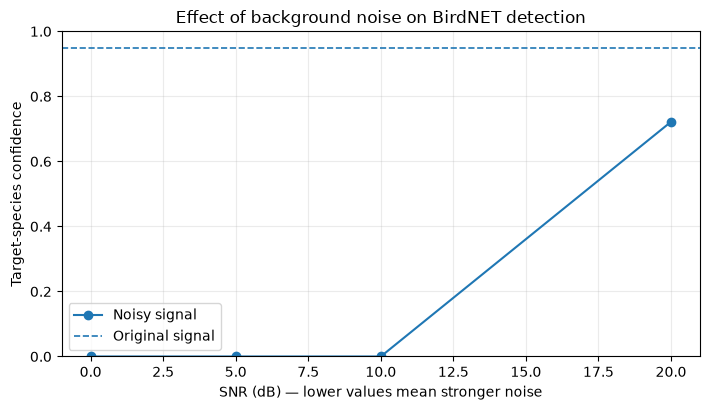

In [24]:
class ExperimentPlotter:
    """Render and save all experiment figures."""

    @staticmethod
    def plot_noise(results: DataFrame, destination: Path) -> None:
        """Plot target-species confidence against SNR.

        :param results: Noise experiment results.
        :type results: DataFrame
        :param destination: Output image path.
        :type destination: Path
        :return: None.
        :rtype: None
        """
        numeric_snr: Series = results["snr_db"].astype(float)
        finite_mask: Series = isfinite(numeric_snr)
        plot_data: DataFrame = results.loc[finite_mask].sort_values("snr_db")
        original_values: Series = results.loc[
            results["condition"] == "original",
            "confidence",
        ]
        original_confidence: float = float(original_values.iloc[0])

        figure_axis: tuple[Figure, Axes] = subplots(figsize=(7.2, 4.2))
        figure: Figure = figure_axis[0]
        axis: Axes = figure_axis[1]
        axis.plot(
            plot_data["snr_db"].astype(float),
            plot_data["confidence"].astype(float),
            marker="o",
            label="Noisy signal",
        )
        axis.axhline(
            original_confidence,
            linestyle="--",
            linewidth=1.2,
            label="Original signal",
        )
        axis.set_xlabel("SNR (dB) — lower values mean stronger noise")
        axis.set_ylabel("Target-species confidence")
        axis.set_ylim(0.0, 1.0)
        axis.set_title("Effect of background noise on BirdNET detection")
        axis.grid(True, alpha=0.25)
        axis.legend()
        figure.tight_layout()
        figure.savefig(destination, dpi=180)
        show()

    @staticmethod
    def plot_overlap(results: DataFrame, destination: Path) -> None:
        """Plot confidence for two overlapping species.

        :param results: Overlap experiment results.
        :type results: DataFrame
        :param destination: Output image path.
        :type destination: Path
        :return: None.
        :rtype: None
        """
        figure_axis: tuple[Figure, Axes] = subplots(figsize=(7.2, 4.2))
        figure: Figure = figure_axis[0]
        axis: Axes = figure_axis[1]
        axis.plot(
            results["mix"],
            results["confidence_a"].astype(float),
            marker="o",
            label="Species A",
        )
        axis.plot(
            results["mix"],
            results["confidence_b"].astype(float),
            marker="o",
            label="Species B",
        )
        axis.set_xlabel("A/B mix (amplitude coefficients)")
        axis.set_ylabel("BirdNET confidence")
        axis.set_ylim(0.0, 1.0)
        axis.set_title("Effect of overlapping bird vocalizations")
        axis.grid(True, alpha=0.25)
        axis.legend()
        figure.tight_layout()
        figure.savefig(destination, dpi=180)
        show()

    @staticmethod
    def plot_threshold(results: DataFrame, destination: Path) -> None:
        """Plot retained detections and species against confidence threshold.

        :param results: Threshold experiment results.
        :type results: DataFrame
        :param destination: Output image path.
        :type destination: Path
        :return: None.
        :rtype: None
        """
        figure_axis: tuple[Figure, Axes] = subplots(figsize=(7.2, 4.2))
        figure: Figure = figure_axis[0]
        axis: Axes = figure_axis[1]
        axis.plot(
            results["threshold"].astype(float),
            results["detections"].astype(int),
            marker="o",
            label="Detections",
        )
        axis.plot(
            results["threshold"].astype(float),
            results["distinct_species"].astype(int),
            marker="o",
            label="Distinct species",
        )
        axis.set_xlabel("Confidence threshold")
        axis.set_ylabel("Count")
        axis.set_title("Effect of the confidence threshold")
        axis.grid(True, alpha=0.25)
        axis.legend()
        figure.tight_layout()
        figure.savefig(destination, dpi=180)
        show()

    @staticmethod
    def plot_spectrogram(
        samples: FloatArray,
        sample_rate: int,
        destination: Path,
    ) -> None:
        """Plot a power spectrogram for an audio signal.

        :param samples: Audio samples.
        :type samples: FloatArray
        :param sample_rate: Sampling rate in hertz.
        :type sample_rate: int
        :param destination: Output image path.
        :type destination: Path
        :return: None.
        :rtype: None
        """
        spectrogram_result: tuple[Float64Array, Float64Array, Float64Array] = spectrogram(
            samples.astype(float64),
            fs=float(sample_rate),
            nperseg=1024,
            noverlap=768,
            scaling="spectrum",
        )
        frequencies: Float64Array = spectrogram_result[0]
        times: Float64Array = spectrogram_result[1]
        power: Float64Array = spectrogram_result[2]
        safe_power: Float64Array = maximum(power, 1e-12)
        power_db: Float64Array = 10.0 * log10(safe_power)

        figure_axis: tuple[Figure, Axes] = subplots(figsize=(8.0, 4.0))
        figure: Figure = figure_axis[0]
        axis: Axes = figure_axis[1]
        mesh: QuadMesh = axis.pcolormesh(
            times,
            frequencies,
            power_db,
            shading="auto",
        )
        axis.set_ylim(0.0, 15_000.0)
        axis.set_xlabel("Time (s)")
        axis.set_ylabel("Frequency (Hz)")
        axis.set_title("Target-segment spectrogram")
        figure.colorbar(mesh, ax=axis, label="Power (dB)")
        figure.tight_layout()
        figure.savefig(destination, dpi=180)
        show()


plotter: ExperimentPlotter = ExperimentPlotter()
plotter.plot_noise(
    noise_results,
    PATHS.results / "experiment_1_noise.png",
)


### Observation

Sur le signal original, le Junco ardoisé (*Junco hyemalis*) est détecté avec une confiance de **0,949** et occupe le premier rang.

À **20 dB**, la détection reste présente, mais sa confiance tombe à **0,722** et l'espèce passe au deuxième rang. À **10 dB, 5 dB et 0 dB**, l'espèce cible n'apparaît plus parmi les prédictions retournées.

**Limite de cette expérience :** une seule réalisation de bruit et un seul segment cible sont utilisés pour chaque SNR. Le résultat décrit donc un comportement contrôlé sur ce cas précis, et non une mesure générale de robustesse du modèle.


# 5. Expérience 2 — vocalisations simultanées

### Hypothèse

Lorsque deux vocalisations sont superposées, BirdNET peut conserver les deux espèces dans ses prédictions, mais la confiance de l'espèce dont la contribution au mélange devient faible devrait diminuer.

### Protocole

1. sélectionner les deux détections les plus confiantes appartenant à deux espèces différentes ;
2. extraire les deux segments correspondants ;
3. les superposer avec les rapports **50/50**, **75/25** et **90/10** ;
4. mesurer la confiance attribuée aux deux espèces dans chaque mélange.

> Les rapports désignent ici des **coefficients d'amplitude** appliqués aux deux signaux avant superposition. Ils ne doivent pas être interprétés comme des pourcentages exacts d'énergie acoustique ou de sonie perçue.


In [25]:
class OverlapExperiment:
    """Run the controlled two-species overlap experiment."""

    def __init__(
        self,
        predictor: BirdNetPredictor,
        audio_processor: AudioProcessor,
        paths: ProjectPaths,
        settings: ExperimentSettings,
    ) -> None:
        """Initialize the experiment.

        :param predictor: BirdNET prediction service.
        :type predictor: BirdNetPredictor
        :param audio_processor: Audio processing service.
        :type audio_processor: AudioProcessor
        :param paths: Project path configuration.
        :type paths: ProjectPaths
        :param settings: Experiment settings.
        :type settings: ExperimentSettings
        :return: None.
        :rtype: None
        """
        self._predictor: BirdNetPredictor = predictor
        self._audio_processor: AudioProcessor = audio_processor
        self._paths: ProjectPaths = paths
        self._settings: ExperimentSettings = settings

    def run(
        self,
        baseline: DataFrame,
        full_audio: FloatArray,
        sample_rate: int,
    ) -> OverlapExperimentOutput:
        """Execute the overlap experiment.

        :param baseline: Baseline BirdNET predictions.
        :type baseline: DataFrame
        :param full_audio: Reference audio samples.
        :type full_audio: FloatArray
        :param sample_rate: Sampling rate in hertz.
        :type sample_rate: int
        :return: Overlap experiment outputs.
        :rtype: OverlapExperimentOutput
        """
        selected_species: tuple[
            DetectionCandidate,
            DetectionCandidate,
        ] = self._predictor.select_two_distinct_species(baseline)
        species_a: DetectionCandidate = selected_species[0]
        species_b: DetectionCandidate = selected_species[1]

        segment_a: FloatArray = self._audio_processor.extract_segment(
            full_audio,
            sample_rate,
            species_a.start_seconds,
            species_a.end_seconds,
        )
        segment_b: FloatArray = self._audio_processor.extract_segment(
            full_audio,
            sample_rate,
            species_b.start_seconds,
            species_b.end_seconds,
        )
        segment_a_path: Path = self._audio_processor.save_audio(
            self._paths.generated_audio / "species_a.wav",
            segment_a,
            sample_rate,
        )
        segment_b_path: Path = self._audio_processor.save_audio(
            self._paths.generated_audio / "species_b.wav",
            segment_b,
            sample_rate,
        )

        result_rows: list[OverlapResult] = []
        for ratio_value in self._settings.mix_ratios:
            ratio: MixRatio = ratio_value
            mixed_samples: FloatArray = self._audio_processor.mix_audio(
                segment_a,
                segment_b,
                ratio,
            )
            mix_name: str = f"mix_{ratio.label.replace('/', '_')}"
            mix_path: Path = self._audio_processor.save_audio(
                self._paths.generated_audio / f"{mix_name}.wav",
                mixed_samples,
                sample_rate,
            )
            mix_predictions: DataFrame = self._predictor.predict(
                mix_path,
                mix_name,
            )
            confidence_a: float = self._predictor.confidence_for_species(
                mix_predictions,
                species_a.species_name,
            )
            confidence_b: float = self._predictor.confidence_for_species(
                mix_predictions,
                species_b.species_name,
            )
            result_rows.append(
                OverlapResult(
                    mix=ratio.label,
                    weight_a=ratio.first,
                    weight_b=ratio.second,
                    species_a=species_a.species_name,
                    confidence_a=confidence_a,
                    species_b=species_b.species_name,
                    confidence_b=confidence_b,
                )
            )

        records: list[dict[str, object]] = [
            result.model_dump() for result in result_rows
        ]
        results: DataFrame = DataFrame(records)
        results.to_csv(
            self._paths.results / "experiment_2_overlap.csv",
            index=False,
        )
        return OverlapExperimentOutput(
            species_a=species_a,
            species_b=species_b,
            segment_a=segment_a,
            segment_b=segment_b,
            segment_a_path=segment_a_path,
            segment_b_path=segment_b_path,
            results=results,
        )


overlap_experiment: OverlapExperiment = OverlapExperiment(
    predictor,
    audio_processor,
    PATHS,
    EXPERIMENT_SETTINGS,
)
overlap_output: OverlapExperimentOutput = overlap_experiment.run(
    baseline_predictions,
    noise_output.full_audio,
    noise_output.sample_rate,
)
overlap_results: DataFrame = overlap_output.results
rms_a: float = audio_processor.rms(overlap_output.segment_a)
rms_b: float = audio_processor.rms(overlap_output.segment_b)

print(
    f"Species A: {overlap_output.species_a.species_name} | "
    f"confidence: {overlap_output.species_a.confidence:.3f}"
)
print(
    f"Species B: {overlap_output.species_b.species_name} | "
    f"confidence: {overlap_output.species_b.confidence:.3f}"
)
print(f"RMS A: {rms_a:.4f} | RMS B: {rms_b:.4f}")
display(Audio(filename=str(overlap_output.segment_a_path)))
display(Audio(filename=str(overlap_output.segment_b_path)))
display(overlap_results)


Preparing CSV export...


Writing CSV: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 12201.61predictions/s, CSV=0 MB]


Preparing CSV export...


Writing CSV: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 16070.13predictions/s, CSV=0 MB]


Preparing CSV export...


Writing CSV: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 16611.10predictions/s, CSV=0 MB]

Species A: Junco hyemalis_Dark-eyed Junco | confidence: 0.949
Species B: Poecile atricapillus_Black-capped Chickadee | confidence: 0.918
RMS A: 0.0058 | RMS B: 0.0017


,mix,weight_a,weight_b,species_a,confidence_a,species_b,confidence_b
0,50/50,0.50,0.50,Junco hyemalis_Dark-eyed Junco,0.921823,Poecile atricapillus_Black-capped Chickadee,0.775239
1,75/25,0.75,0.25,Junco hyemalis_Dark-eyed Junco,0.946072,Poecile atricapillus_Black-capped Chickadee,0.651646
2,90/10,0.90,0.10,Junco hyemalis_Dark-eyed Junco,0.946808,Poecile atricapillus_Black-capped Chickadee,0.419066


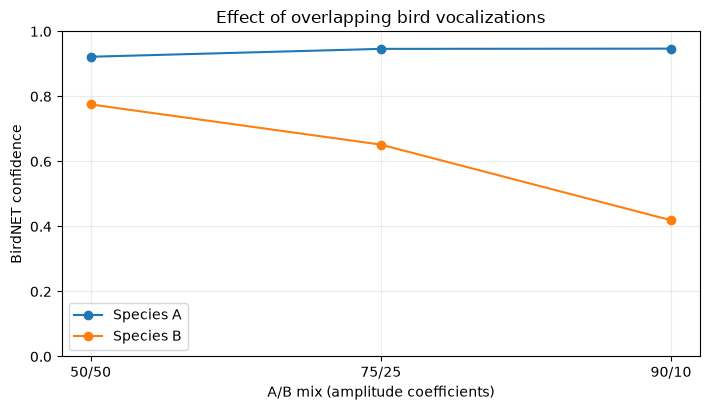

In [26]:
plotter.plot_overlap(
    overlap_results,
    PATHS.results / "experiment_2_overlap.png",
)


### Observation

Les deux espèces restent détectées dans les trois mélanges étudiés. La confiance de l'espèce A reste élevée, de **0,922** à **0,947**.

Pour l'espèce B, la confiance diminue avec son poids dans le mélange : **0,775** en 50/50, **0,652** en 75/25, puis **0,419** en 90/10.

**Limites :** cette expérience ne concerne que deux espèces et trois rapports d'amplitude. De plus, les segments n'ont pas été égalisés en sonie avant mélange ; les coefficients ne décrivent donc pas exactement le rapport perceptif entre les deux sources.


# 6. Expérience 3 — effet du seuil de confiance

### Hypothèse

Augmenter le seuil de confiance doit réduire le nombre de détections conservées et, progressivement, le nombre d'espèces distinctes retournées.

### Protocole

Les prédictions du fichier original sont filtrées avec quatre seuils : **0,10**, **0,25**, **0,50** et **0,75**. Pour chaque seuil, on compte :

- le nombre total de détections conservées ;
- le nombre d'espèces distinctes représentées.

> Le fichier d'exemple ne possède pas d'annotation exhaustive de référence. Cette expérience **ne calcule donc ni précision, ni rappel, ni F1-score**. Elle décrit uniquement l'effet du filtrage par seuil.


In [27]:
class ThresholdExperiment:
    """Measure how confidence thresholds change retained predictions."""

    def __init__(
        self,
        paths: ProjectPaths,
        settings: ExperimentSettings,
    ) -> None:
        """Initialize the experiment.

        :param paths: Project path configuration.
        :type paths: ProjectPaths
        :param settings: Experiment settings.
        :type settings: ExperimentSettings
        :return: None.
        :rtype: None
        """
        self._paths: ProjectPaths = paths
        self._settings: ExperimentSettings = settings

    def run(self, baseline: DataFrame) -> DataFrame:
        """Execute the threshold experiment.

        :param baseline: Baseline BirdNET predictions.
        :type baseline: DataFrame
        :return: Threshold experiment results.
        :rtype: DataFrame
        """
        result_rows: list[ThresholdResult] = []
        for threshold_value_raw in self._settings.confidence_thresholds:
            threshold_value: float = float(threshold_value_raw)
            retained: DataFrame = baseline.loc[
                baseline["confidence"] >= threshold_value
            ]
            detections: int = int(len(retained))
            distinct_species: int = int(retained["species_name"].nunique())
            result_rows.append(
                ThresholdResult(
                    threshold=threshold_value,
                    detections=detections,
                    distinct_species=distinct_species,
                )
            )

        records: list[dict[str, object]] = [
            result.model_dump() for result in result_rows
        ]
        results: DataFrame = DataFrame(records)
        results.to_csv(
            self._paths.results / "experiment_3_threshold.csv",
            index=False,
        )
        return results


threshold_experiment: ThresholdExperiment = ThresholdExperiment(
    PATHS,
    EXPERIMENT_SETTINGS,
)
threshold_results: DataFrame = threshold_experiment.run(baseline_predictions)
display(threshold_results)


,threshold,detections,distinct_species
0,0.10,86,15
1,0.25,69,8
2,0.50,54,7
3,0.75,29,6


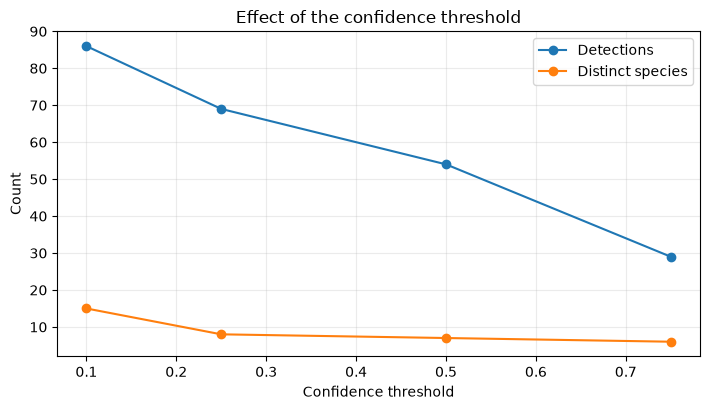

In [28]:
plotter.plot_threshold(
    threshold_results,
    PATHS.results / "experiment_3_threshold.png",
)


### Observation

Lorsque le seuil passe de **0,10** à **0,75**, le nombre de détections conservées passe de **86** à **29**, tandis que le nombre d'espèces distinctes passe de **15** à **6**.

La diminution la plus forte du nombre d'espèces apparaît entre **0,10 et 0,25**, avec un passage de **15 à 8 espèces**.

Sans vérité terrain exhaustive, ces résultats permettent seulement de quantifier l'effet du seuil ; ils ne permettent pas d'affirmer qu'un seuil est meilleur qu'un autre en termes de qualité de classification.


# 7. Visualisation temps-fréquence

Le spectrogramme du segment cible permet de relier les mesures numériques au contenu fréquentiel du signal réellement perturbé dans l'expérience 1.


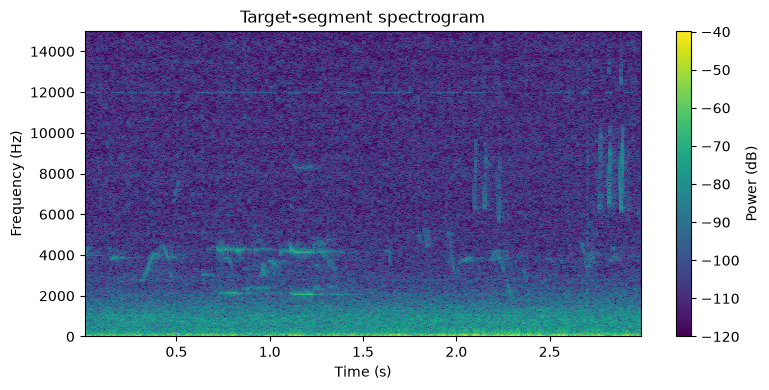

In [29]:
plotter.plot_spectrogram(
    noise_output.target_segment,
    noise_output.sample_rate,
    PATHS.results / "target_spectrogram.png",
)


# 8. Fichiers produits

Les sorties utiles au rapport sont écrites automatiquement dans `results/`. Les signaux intermédiaires générés sont conservés dans `generated_audio/` afin de pouvoir écouter les perturbations appliquées.


In [30]:
result_files: list[Path] = sorted(PATHS.results.glob("*"))
for result_file_value in result_files:
    result_file: Path = result_file_value
    portable_result: Path = result_file.relative_to(PATHS.root)
    print(portable_result)


results/baseline_predictions.csv
results/experiment_1_noise.csv
results/experiment_1_noise.png
results/experiment_2_overlap.csv
results/experiment_2_overlap.png
results/experiment_3_threshold.csv
results/experiment_3_threshold.png
results/mix_50_50.csv
results/mix_75_25.csv
results/mix_90_10.csv
results/noise_original.csv
results/noise_snr_0db.csv
results/noise_snr_10db.csv
results/noise_snr_20db.csv
results/noise_snr_5db.csv
results/target_spectrogram.png


# 9. Conclusion expérimentale

Les trois tests contrôlés mettent en évidence des comportements distincts de BirdNET :

- la détection de l'espèce cible se dégrade nettement lorsque le bruit augmente ;
- deux espèces peuvent rester détectables lorsqu'elles sont superposées, mais la confiance de la source la moins représentée diminue ;
- augmenter le seuil de confiance réduit fortement le nombre de détections et d'espèces conservées.

Ces observations sont cohérentes avec l'objectif d'une **expérimentation exploratoire et reproductible**, mais elles ne doivent pas être interprétées comme une évaluation générale des performances de BirdNET.

## Limites et prolongements

Les principales limites sont le nombre réduit de segments, l'utilisation d'une seule réalisation de bruit par SNR, le mélange de seulement deux espèces et l'absence de vérité terrain exhaustive pour l'expérience sur les seuils.

Une évaluation plus générale nécessiterait un jeu de données fortement annoté, par exemple un sous-ensemble adapté de **BirdSet**, afin de calculer des métriques multi-label telles que la précision, le rappel ou la mean Average Precision et d'étudier la variabilité entre sites ou régions.
